# FFT
Lê um arquivo PDM gravado pelo ESP32 (com ou sem cabeçalho) e plota o gráfico da FFT em escala semilogarítimica.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt

def fftplot(filename, fs, bitrate):
    #leitura do arquivo
    if bitrate == 16:
        data = np.fromfile(filename, dtype=np.uint16)
    if bitrate == 32:
        data = np.fromfile(filename, dtype=np.uint32)
    data = data[len(data)//2:]
    data = data.byteswap()
    data2 = data.view(np.uint8)
    bits = np.unpackbits(data2) #bytes para bits
    pdm_signal = 2 * bits.astype(np.float64) - 1 #transformar pra bipolar
    
    # calcular fft
    N = len(pdm_signal)
    spec = np.fft.rfft(pdm_signal)
    freq = np.fft.rfftfreq(N, 1/fs)

    # plot
    fig, ax = plt.subplots()
    ax.semilogx(freq, 20*np.log10(spec), linewidth=0.5)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title('Espectro de Frequência (FFT)')
    plt.grid(True, which="both", linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [2]:
def fftplot_filtered(filename, fs, bitrate, fc, order, decim):
    #leitura do arquivo
    if bitrate == 16:
        data = np.fromfile(filename, dtype=np.uint16)
    if bitrate == 32:
        data = np.fromfile(filename, dtype=np.uint32)
    data = data[len(data)//2:]
    data = data.byteswap()
    data2 = data.view(np.uint8)
    bits = np.unpackbits(data2) #bytes para bits
    pdm_signal = 2 * bits.astype(np.float64) - 1 #transformar pra bipolar

    #filtering
    norm_fc = fc / (fs* 0.5)
    b,a = butter(N=order, Wn=norm_fc, btype='low')
    filtered_data = lfilter(b,a,pdm_signal)
    
    #decimation
    fs_decim = fs/decim
    pcm_signal = filtered_data[::decim]
    
    # calcular fft
    N = len(pcm_signal)
    spec = np.fft.rfft(pcm_signal)
    freq = np.fft.rfftfreq(N, 1/fs_decim)

    # plot
    fig, ax = plt.subplots()
    ax.semilogx(freq, 20*np.log10(spec), linewidth=0.5)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title('Espectro de Frequência (FFT)')
    plt.grid(True, which="both", linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [3]:
def fftplot_lowpass(filename, fs, bitrate, fc, order, decim):
    #leitura do arquivo
    if bitrate == 16:
        data = np.fromfile(filename, dtype=np.uint16)
    if bitrate == 32:
        data = np.fromfile(filename, dtype=np.uint32)
    data = data[len(data)//2:]
    data = data.byteswap()
    data2 = data.view(np.uint8)
    bits = np.unpackbits(data2) #bytes para bits
    pdm_signal = 2 * bits.astype(np.float64) - 1 #transformar pra bipolar

    #filtering
    norm_fc = fc / (fs* 0.5)
    b,a = butter(N=order, Wn=norm_fc, btype='low')
    filtered_data = filtfilt(b,a,pdm_signal)
    
    #decimation
    #fs_decim = fs/decim
    #pcm_signal = filtered_data[::decim]
    
    # calcular fft
    N = len(filtered_data)
    spec = np.fft.rfft(filtered_data)
    freq = np.fft.rfftfreq(N, 1/fs)

    # plot
    fig, ax = plt.subplots()
    ax.semilogx(freq, 20*np.log10(spec), linewidth=0.5)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title('Espectro de Frequência (FFT)')
    plt.grid(True, which="both", linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.io import wavfile

def fftplot_filtered_wav(filename, fs, bitrate, fc, order, decim, output_wav="output.wav"):
    # 1. Leitura e Conversão PDM
    dtype = np.uint16 if bitrate == 16 else np.uint32
    data = np.fromfile(filename, dtype=dtype)
    data = data[len(data)//8:].byteswap()
    data2 = data.view(np.uint8)
    bits = np.unpackbits(data2)
    pdm_signal = 2.0 * bits.astype(np.float64) - 1.0

    # 2. Filtragem
    # Correção da normalização: Wn = fc / (fs/2)
    norm_fc = fc / (fs * 0.5)
    b, a = butter(N=order, Wn=norm_fc, btype='low')
    filtered_data = filtfilt(b, a, pdm_signal)
    
    # 3. Decimação
    fs_decim = int(fs / decim)
    pcm_signal = filtered_data[::decim]
    
    # --- SALVAMENTO DO ARQUIVO DE ÁUDIO ---
    # Normalização para evitar clipping (deixa um headroom de 10%)
    max_val = np.max(np.abs(pcm_signal))
    if max_val > 0:
        audio_normalized = pcm_signal / max_val * 0.9
    else:
        audio_normalized = pcm_signal

    # Conversão para Int16 (PCM 16-bit)
    audio_int16 = (audio_normalized * 32767).astype(np.int16)
    
    # Escrita do arquivo WAV
    wavfile.write(output_wav, fs_decim, audio_int16)
    print(f"Áudio salvo com sucesso: {output_wav}")
    # --------------------------------------
    
    # 4. Cálculo FFT (usando magnitude absoluta)
    N = len(pcm_signal)
    spec = np.abs(np.fft.rfft(pcm_signal))
    spec = (spec)^2 / (fs*N)
    freq = np.fft.rfftfreq(N, 1/fs_decim)

    # 5. Plotagem
    fig, ax = plt.subplots()
    ax.semilogx(freq, 20 * np.log10(spec + 1e-12), linewidth=0.5)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'Espectro de Frequência - Fs Final: {fs_decim} Hz')
    plt.grid(True, which="both", linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

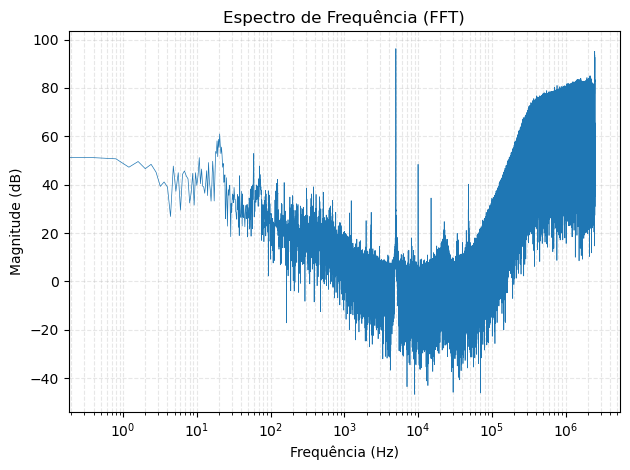

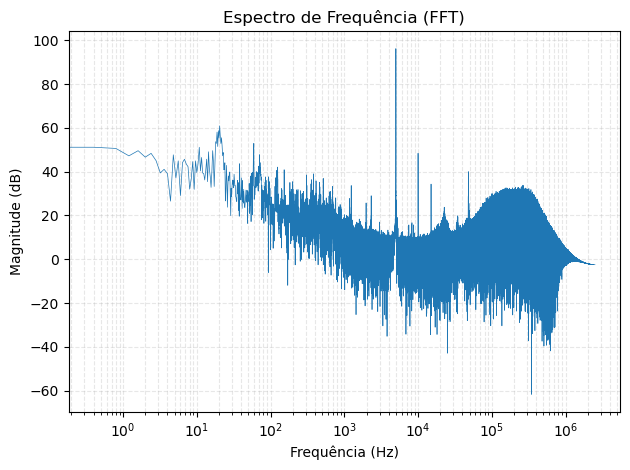

Áudio salvo com sucesso: audio/output.wav


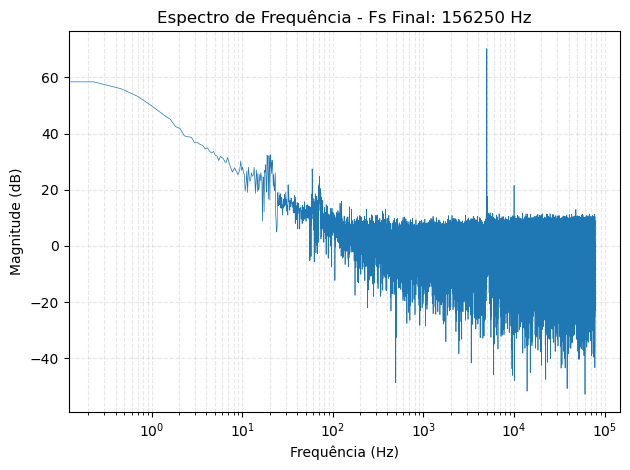

In [8]:
fcorte = 1e5
ordem = 2
fftplot('data/13-02--rtos-e-baremetal-funcionando/pdm32bits-rtos/pdm32bits-rtos_5khz_alto02.RAW', 5e6, 32)
fftplot_lowpass('data/13-02--rtos-e-baremetal-funcionando/pdm32bits-rtos/pdm32bits-rtos_5khz_alto02.RAW', 5e6, 32, fcorte,ordem,32)
fftplot_filtered_wav('data/13-02--rtos-e-baremetal-funcionando/pdm32bits-rtos/pdm32bits-rtos_5khz_alto02.RAW', 5e6, 32, fcorte,ordem,32, output_wav="audio/output.wav")